> kaggle link: https://www.kaggle.com/code/rajeshphulwaria/text-preprocessing-imdb

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [2]:
df = pd.read_csv("../input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")
df.head(10)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [4]:
df['review'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 50000 entries, 0 to 49999
Series name: review
Non-Null Count  Dtype 
--------------  ----- 
50000 non-null  object
dtypes: object(1)
memory usage: 390.8+ KB


In [5]:
df['review'].values[0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [10]:
from bs4 import BeautifulSoup
# function to clean html tags of text
def clean_html(text):
    clean = BeautifulSoup(text, 'html.parser').get_text()
    return clean

In [9]:
clean_html("<h1>hello world! fuck you bitch.</h1>")

'hello world! fuck you bitch.'

In [16]:
# clean html tags from dataset
df['review'] = df['review'].str.lower().apply(clean_html)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [19]:
df['review'].values[0]

"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows wo

In [24]:
from textblob import TextBlob
# function which returns correct spell of misspelled words
def spell_correct(text):
    corrected = TextBlob(text)
    return str(corrected.correct())


In [25]:
spell_correct("Mechine larnng")

'Machine learning'

In [30]:
first_sentiment = spell_correct(df['review'].values[0])

In [31]:
first_sentiment

"one of the other reviews has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutally and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punched with regards to drugs, sex or violence. its is hardware, in the classic use of the word.it is called oz as that is the nickname given to the onward maximum security state penitentiary. it focused mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..organs, muslin, gangstas, nations, christians, italians, irish and more....so snuffles, death stares, podgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows would

In [38]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
# generate tokens
tokens = [word_tokenize(line) for line in sent_tokenize(first_sentiment)]
tokens[3]

['this',
 'show',
 'pulls',
 'no',
 'punched',
 'with',
 'regards',
 'to',
 'drugs',
 ',',
 'sex',
 'or',
 'violence',
 '.']

<Axes: xlabel='sentiment'>

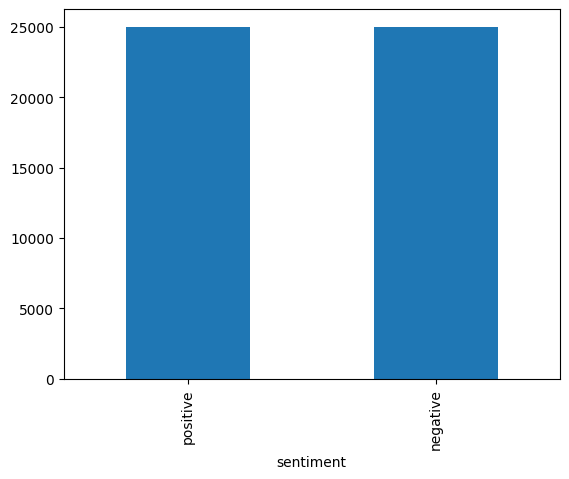

In [46]:
df['sentiment'].value_counts().plot(kind='bar')

In [47]:
def tokenize_df(review):
    tokens = [word_tokenize(sentence) for sentence in sent_tokenize(review)]
    return tokens

In [53]:
# applying tokenization on first 500 rows
df_500 = df.head(500)
tokenized_reviews_500 = df_500['review'].apply(tokenize_df)

In [55]:
tokenized_reviews_500.head()

0    [[one, of, the, other, reviewers, has, mention...
1    [[a, wonderful, little, production, .], [the, ...
2    [[i, thought, this, was, a, wonderful, way, to...
3    [[basically, there, 's, a, family, where, a, l...
4    [[petter, mattei, 's, ``, love, in, the, time,...
Name: review, dtype: object

In [63]:
from nltk.stem import PorterStemmer
# stemming on reviews
# function to apply stemming on dataset's words
def stem_data(text_list):
    stemmer = PorterStemmer()
    stemmed_list = [[stemmer.stem(word) for word in words] for words in text_list]
    return stemmed_list

In [64]:
tokenized_reviews_500.apply(stem_data)

0      [[one, of, the, other, review, ha, mention, th...
1      [[a, wonder, littl, product, .], [the, film, t...
2      [[i, thought, thi, wa, a, wonder, way, to, spe...
3      [[basic, there, 's, a, famili, where, a, littl...
4      [[petter, mattei, 's, ``, love, in, the, time,...
                             ...                        
495    [[``, american, nightmar, '', is, offici, tie,...
496    [[first, off, ,, i, have, to, say, that, i, lo...
497    [[thi, movi, wa, extrem, bore, .], [i, onli, l...
498    [[i, wa, disgust, by, thi, movi, .], [no, it, ...
499    [[such, a, joyou, world, ha, been, creat, for,...
Name: review, Length: 500, dtype: object

# Conclusion
> Applied basic **Text Preprocessing** on given dataset (IMDB movies) such as
- Lowercasing
- HTML Parsing
- Spell Correction
- Tokenization : Word-tokenization & Sentence-tokenization
- Stemming (BeautifulSoup)